In [1]:
import torch as tr
import numpy as np
import pandas as pd
import os 
from datetime import datetime
from tqdm import tqdm
from torch.utils.data import DataLoader
import time
import sys

# --- PROJECT IMPORTS ---
current_dir = os.getcwd() 
project_root = os.path.abspath(os.path.join(current_dir, '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
from src.dataset import SeqDataset, pad_batch 
from src.metrics import contact_f1
from src.utils import save_config, load_model
# --- UTILITIES ---

def get_timestamp():
    return datetime.now().strftime("%Y%m%d_%H%M%S")

In [2]:
BASE_DATA_DIR = "../data/simfolds/simfolds_max128/joined/"

sim = "sim90"
DATA_DIR = os.path.join(BASE_DATA_DIR, sim)
conf = {
    "train_path": f"{DATA_DIR}/train.csv",
    "val_path": f"{DATA_DIR}/valid.csv",
    "log_path": f"logs/",
    "batch_size": 4,
    "lr": 1e-3,
    "epochs": 3,
    "timesteps": 10,
    "profile_batches": 20,
    "note": f"simfold profiler: {sim}. Archive II max 128.",
}
model = load_model(config=conf, eval=False)

In [10]:
# count parameters of the model:
base_config = conf.copy()
ts = range(1, 200)
model_params = []
ts_evaluated = []
for t in ts:
    config = base_config.copy()
    config["timesteps"] = t
    model = load_model(config=config, eval=False)
    model_params.append(sum(p.numel() for p in model.parameters()))
    ts_evaluated.append(model.time_steps)

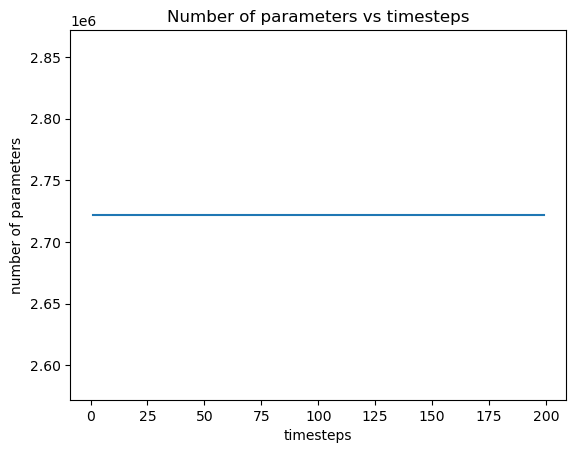

In [13]:
import matplotlib.pyplot as plt
plt.plot(ts, model_params, label="model parameters") 
plt.xlabel("timesteps")
plt.ylabel("number of parameters")
plt.title("Number of parameters vs timesteps")
plt.show()